# 01 · Clustering: K-Means, Hierarchical, DBSCAN, OPTICS, GMM & Mean Shift

**Phase 6 — Section 6.1 Clustering | Notebook 1 of 1**

### Why this matters
Every model in Phase 5 needed labels. Real data very often has NONE — nobody tells you in
advance which customers form natural groups. Clustering finds that structure on its own.
This notebook covers six genuinely different ways to define "a group," on a real,
classic customer dataset.

### The real dataset: Mall Customers

200 real (anonymized) shopping mall customers — age, annual income, and a "spending score"
assigned by the mall based on purchasing behavior. Loaded directly from GitHub.

```
https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)
df.columns = ["customer_id", "gender", "age", "annual_income", "spending_score"]
print(df.shape)
df.head()

(200, 5)


,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 0. A quick look before clustering anything

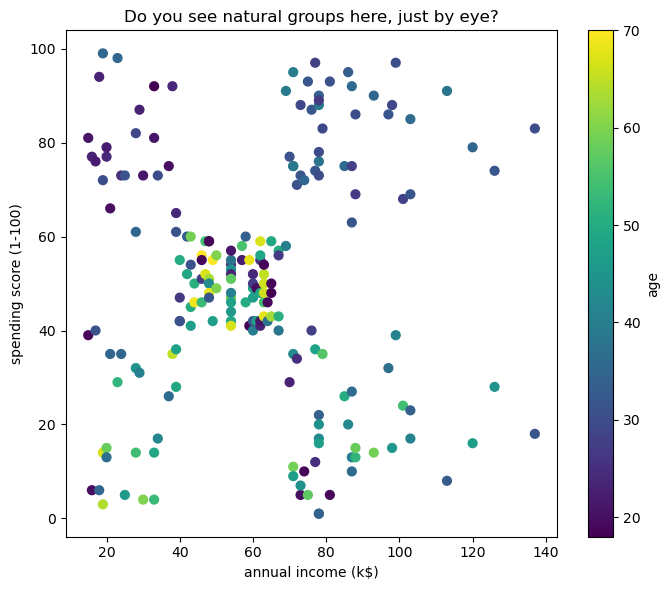

In [2]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(df["annual_income"], df["spending_score"], c=df["age"], cmap="viridis", s=40)
ax.set_xlabel("annual income (k$)"); ax.set_ylabel("spending score (1-100)")
fig.colorbar(scatter, label="age")
ax.set_title("Do you see natural groups here, just by eye?")
plt.tight_layout(); plt.show()

> 💡 We'll cluster on `annual_income` and `spending_score` — even without any labels,
> distinct customer "types" (high income/low spending, low income/high spending, etc.)
> should be visually obvious once we color by cluster. Always scale features before
> distance-based clustering (Section 2.2/Module 1.1's norms) — income and spending score
> are on very different raw scales.

In [3]:
from sklearn.preprocessing import StandardScaler

X = df[["annual_income", "spending_score"]].values
X_scaled = StandardScaler().fit_transform(X)

## 1. K-Means — the default, distance-to-centroid approach

K-Means picks `k` centroids, assigns every point to its nearest centroid, moves each
centroid to the mean of its assigned points, and repeats until stable. You must choose `k`
in advance — the **elbow method** and **silhouette score** both help.

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_

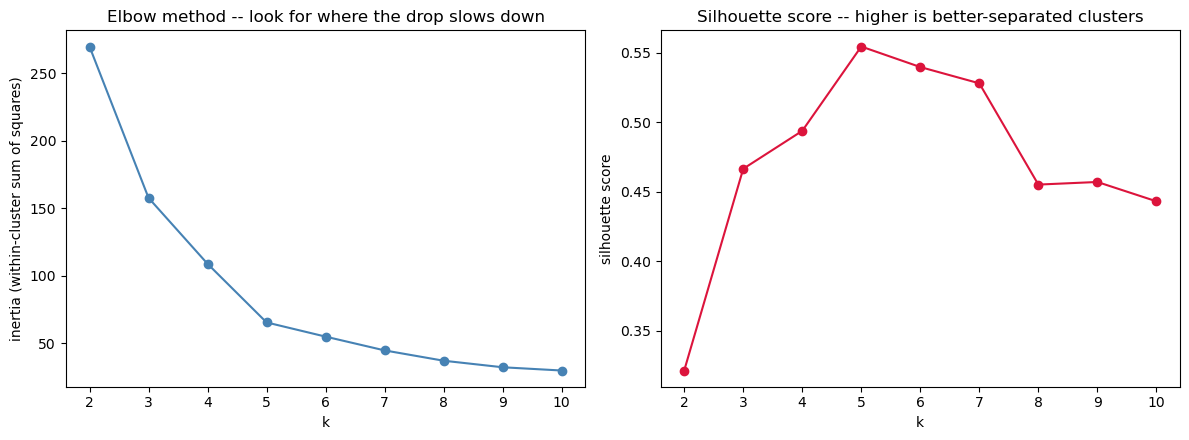

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow method -- look for where the drop slows down")

axes[1].plot(list(k_range), silhouettes, marker="o", color="crimson")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score -- higher is better-separated clusters")
plt.tight_layout(); plt.show()

> 💡 **Silhouette score** measures how much closer a point is to its own cluster than to
> the next-nearest one, averaged over all points (ranges -1 to 1). Both charts here should
> point toward a similar "sweet spot" k — when they disagree, that's worth investigating
> rather than picking blindly.

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


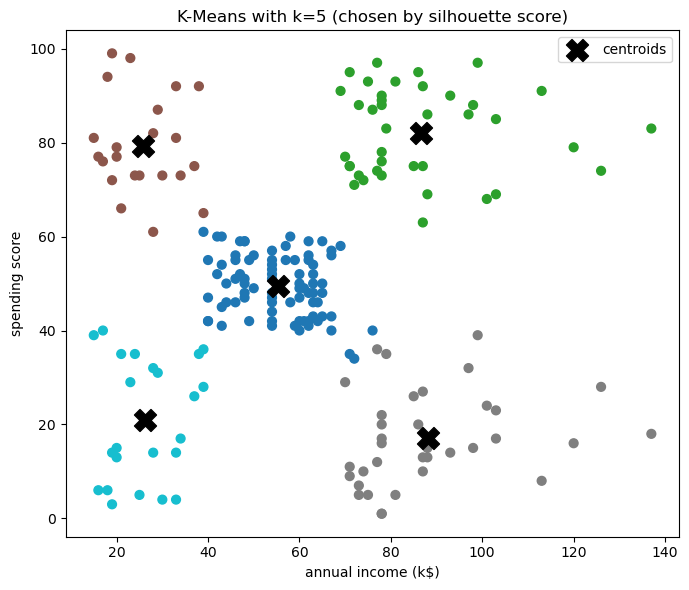

In [5]:
best_k = int(np.array(k_range)[np.argmax(silhouettes)])
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_scaled)
df["kmeans_cluster"] = kmeans.labels_

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(df["annual_income"], df["spending_score"], c=df["kmeans_cluster"], cmap="tab10", s=40)
centroids_original_scale = StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1], marker="X", s=250, color="black", label="centroids")
ax.set_xlabel("annual income (k$)"); ax.set_ylabel("spending score")
ax.legend()
ax.set_title(f"K-Means with k={best_k} (chosen by silhouette score)")
plt.tight_layout(); plt.show()

## 2. Hierarchical Clustering — building a tree of nested groups

Instead of committing to one `k` upfront, hierarchical clustering builds a full tree
(**dendrogram**) merging the closest points/clusters step by step. You choose `k` by
"cutting" the tree at a chosen height — after seeing the whole structure.

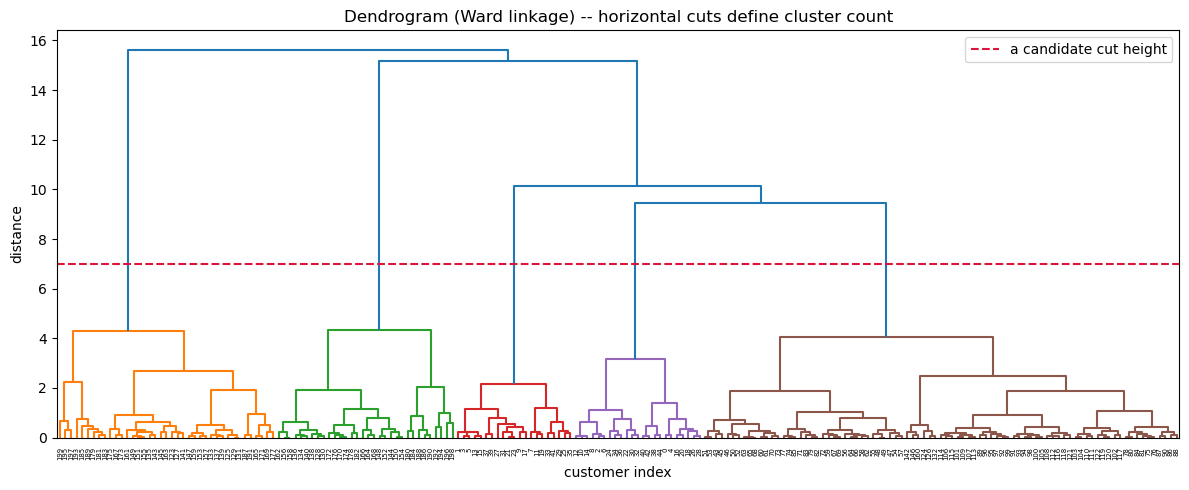

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

linkage_matrix = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_matrix, ax=ax, color_threshold=7)
ax.set_title("Dendrogram (Ward linkage) -- horizontal cuts define cluster count")
ax.set_xlabel("customer index"); ax.set_ylabel("distance")
ax.axhline(7, color="crimson", ls="--", label="a candidate cut height")
ax.legend()
plt.tight_layout(); plt.show()

In [7]:
hierarchical_labels = fcluster(linkage_matrix, t=7, criterion="distance")
df["hierarchical_cluster"] = hierarchical_labels
print(f"number of clusters at this cut height: {len(set(hierarchical_labels))}")
print(f"agreement with K-Means (just as a sanity comparison, not a hard requirement): ")
print(pd.crosstab(df["kmeans_cluster"], df["hierarchical_cluster"]))

number of clusters at this cut height: 5
agreement with K-Means (just as a sanity comparison, not a hard requirement): 
hierarchical_cluster   1   2   3   4   5
kmeans_cluster                          
0                      0   0   0   0  81
1                     39   0   0   0   0
2                      0   0  21   0   1
3                      0  32   0   0   3
4                      0   0   0  23   0


## 3. DBSCAN — density-based, no need to pick `k` at all

DBSCAN groups points that are densely packed together, and explicitly labels sparse,
isolated points as **noise** (`-1`) rather than forcing them into a cluster. It needs two
parameters instead: `eps` (neighborhood radius) and `min_samples`.

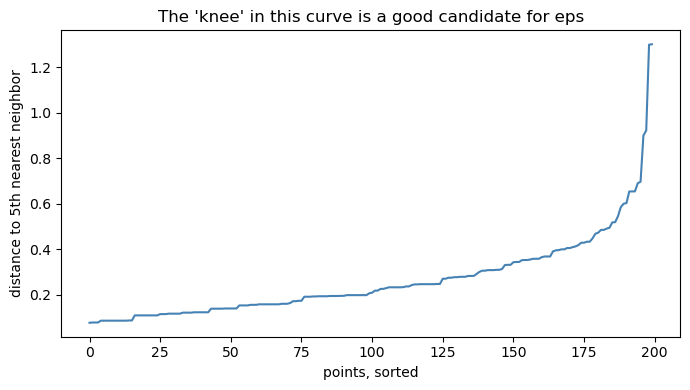

In [8]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# choosing eps: plot the distance to each point's k-th nearest neighbor, look for the "knee"
neighbors = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
sorted_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sorted_distances, color="steelblue")
ax.set_xlabel("points, sorted"); ax.set_ylabel("distance to 5th nearest neighbor")
ax.set_title("The 'knee' in this curve is a good candidate for eps")
plt.tight_layout(); plt.show()

DBSCAN found 6 clusters and flagged 23 points as noise


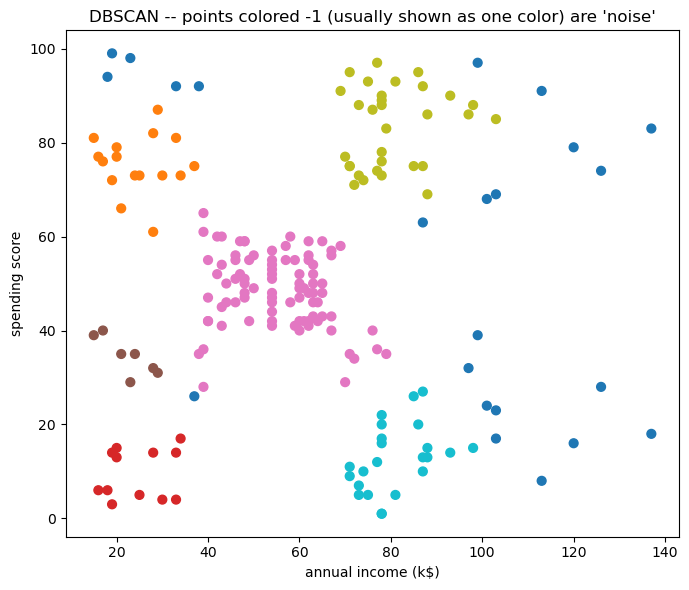

In [9]:
dbscan = DBSCAN(eps=0.35, min_samples=5).fit(X_scaled)
df["dbscan_cluster"] = dbscan.labels_

n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = (dbscan.labels_ == -1).sum()
print(f"DBSCAN found {n_clusters} clusters and flagged {n_noise} points as noise")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["annual_income"], df["spending_score"], c=df["dbscan_cluster"], cmap="tab10", s=40)
ax.set_xlabel("annual income (k$)"); ax.set_ylabel("spending score")
ax.set_title("DBSCAN -- points colored -1 (usually shown as one color) are 'noise'")
plt.tight_layout(); plt.show()

> 💡 **Where you'll use this directly:** DBSCAN's ability to explicitly flag outliers as
> "noise" rather than force-fitting them into the nearest cluster makes it a natural fit
> for datasets where you expect a meaningful number of true outliers — this is why it also
> shows up as an anomaly-detection technique (Section 6.3).

## 4. OPTICS — DBSCAN's generalization across multiple densities

DBSCAN uses ONE fixed `eps` for the whole dataset — a problem if some real clusters are
naturally denser than others. OPTICS builds an ordering that reveals cluster structure at
**varying densities simultaneously**, without needing one global `eps`.

OPTICS found 11 clusters


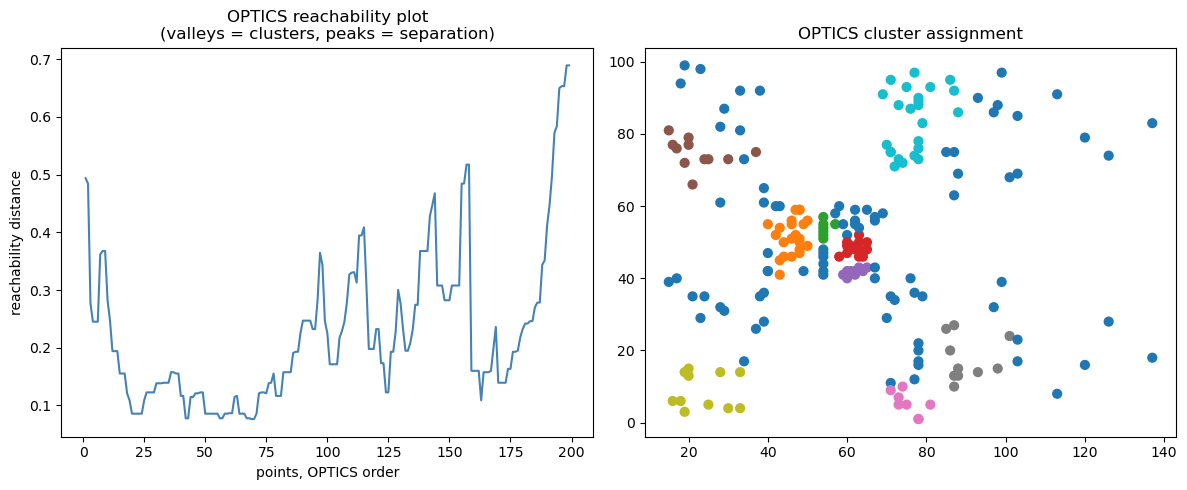

In [10]:
from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=5, xi=0.05).fit(X_scaled)
df["optics_cluster"] = optics.labels_

n_clusters_optics = len(set(optics.labels_)) - (1 if -1 in optics.labels_ else 0)
print(f"OPTICS found {n_clusters_optics} clusters")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(optics.reachability_[optics.ordering_], color="steelblue")
axes[0].set_title("OPTICS reachability plot\n(valleys = clusters, peaks = separation)")
axes[0].set_xlabel("points, OPTICS order"); axes[0].set_ylabel("reachability distance")

axes[1].scatter(df["annual_income"], df["spending_score"], c=df["optics_cluster"], cmap="tab10", s=40)
axes[1].set_title("OPTICS cluster assignment")
plt.tight_layout(); plt.show()

## 5. Gaussian Mixture Models — soft, probabilistic clustering

K-Means makes a hard assignment (a point belongs to exactly one cluster). A **Gaussian
Mixture Model** assumes the data was generated by a mix of several Gaussian distributions
(Module 1.3!) and gives you a full PROBABILITY of membership in each cluster — useful when
cluster boundaries are genuinely fuzzy.

In [11]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=best_k, random_state=42).fit(X_scaled)
df["gmm_cluster"] = gmm.predict(X_scaled)
gmm_probabilities = gmm.predict_proba(X_scaled)

print("Example: customer 0's probability of belonging to each cluster:")
print(np.round(gmm_probabilities[0], 3))

# Find the customers GMM is LEAST certain about -- a hard-assignment method (K-Means)
# can't even express this kind of uncertainty
uncertainty = 1 - gmm_probabilities.max(axis=1)
most_uncertain_idx = np.argsort(uncertainty)[-5:]
print("\nThe 5 customers GMM is least certain how to cluster:")
df.iloc[most_uncertain_idx][["annual_income", "spending_score", "gmm_cluster"]]

Example: customer 0's probability of belonging to each cluster:
[0.    0.    0.001 0.    0.999]

The 5 customers GMM is least certain how to cluster:


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,annual_income,spending_score,gmm_cluster
160,79,35,0
27,28,61,2
49,40,42,0
48,40,42,0
124,70,29,3


## 6. Mean Shift — climbing toward the nearest density peak

Mean Shift doesn't require choosing `k` either — it iteratively shifts each point toward
the nearest area of highest data density (a "mode"), and points that converge to the same
mode form a cluster.

Mean Shift found 5 clusters automatically


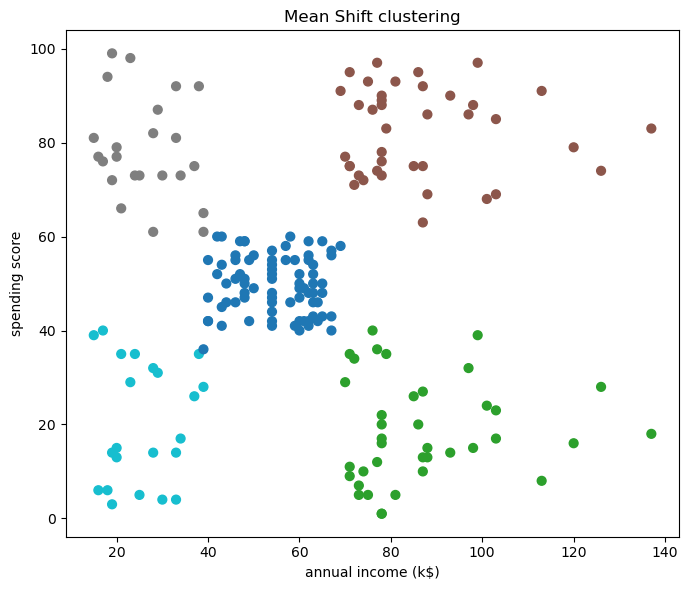

In [12]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X_scaled, quantile=0.15)
mean_shift = MeanShift(bandwidth=bandwidth).fit(X_scaled)
df["meanshift_cluster"] = mean_shift.labels_

print(f"Mean Shift found {len(set(mean_shift.labels_))} clusters automatically")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["annual_income"], df["spending_score"], c=df["meanshift_cluster"], cmap="tab10", s=40)
ax.set_xlabel("annual income (k$)"); ax.set_ylabel("spending score")
ax.set_title("Mean Shift clustering")
plt.tight_layout(); plt.show()

## 7. Side-by-side: all six methods, same data

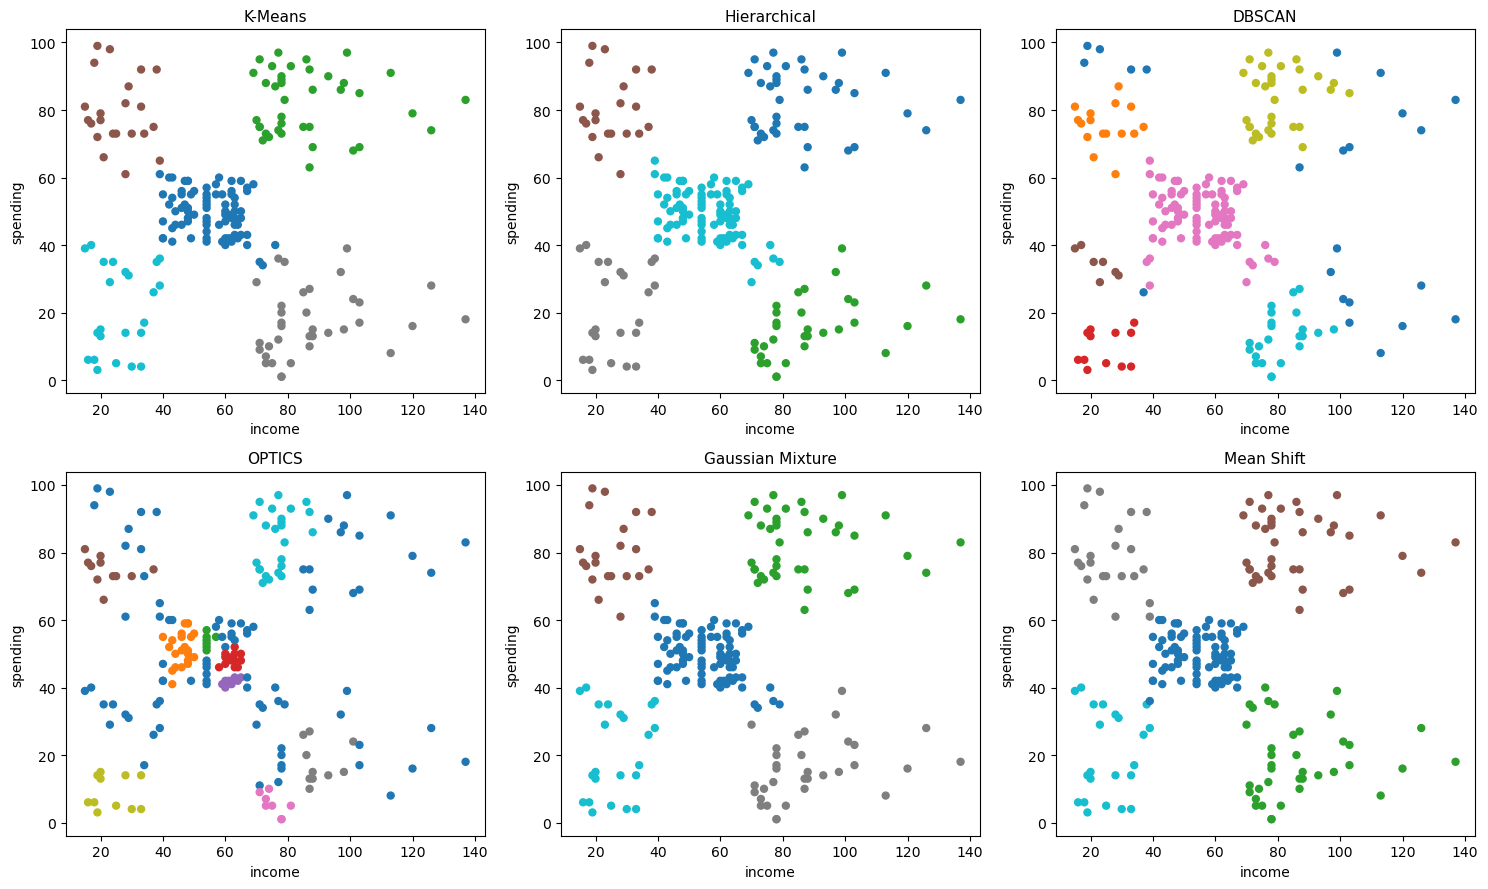

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
methods = ["kmeans_cluster", "hierarchical_cluster", "dbscan_cluster", "optics_cluster", "gmm_cluster", "meanshift_cluster"]
titles = ["K-Means", "Hierarchical", "DBSCAN", "OPTICS", "Gaussian Mixture", "Mean Shift"]

for ax, method, title in zip(axes.ravel(), methods, titles):
    ax.scatter(df["annual_income"], df["spending_score"], c=df[method], cmap="tab10", s=25)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("income"); ax.set_ylabel("spending")

plt.tight_layout(); plt.show()

| Method | Needs `k`? | Handles noise/outliers? | Cluster shape assumption |
|---|---|---|---|
| K-Means | Yes | No | Roughly spherical, similar size |
| Hierarchical | No (choose after) | No | Depends on linkage method |
| DBSCAN | No | Yes (explicit noise label) | Arbitrary shape, uniform density |
| OPTICS | No | Yes | Arbitrary shape, VARYING density |
| Gaussian Mixture | Yes | No | Elliptical (Gaussian) |
| Mean Shift | No (auto via bandwidth) | Not explicitly | Follows density peaks |

## 🧪 Practice Exercises

**1.** Re-run K-Means with `k=3` and `k=7` (not the silhouette-chosen best). Compute the
silhouette score for each and compare to the "best" k found above.

**2.** Add `age` as a third clustering feature (scale it too) and re-run K-Means. Does the
cluster count or the resulting groups change meaningfully?

**3.** For DBSCAN, try `eps=0.2` (smaller) and `eps=0.6` (larger) instead of `0.35`. What
happens to the number of clusters and the amount of "noise" in each case?

In [ ]:
# --- Exercise 1 ---
for k in [3, 7]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    print(f"k={k}: silhouette={silhouette_score(X_scaled, km.labels_):.4f}")
print(f"'best' k={best_k}: silhouette={max(silhouettes):.4f}")

In [ ]:
# --- Exercise 2 ---
X_3d = df[["annual_income", "spending_score", "age"]].values
X_3d_scaled = StandardScaler().fit_transform(X_3d)
km_3d = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_3d_scaled)
print(f"2D clustering silhouette: {max(silhouettes):.4f}")
print(f"3D (with age) clustering silhouette: {silhouette_score(X_3d_scaled, km_3d.labels_):.4f}")

In [ ]:
# --- Exercise 3 ---
for eps in [0.2, 0.6]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_scaled)
    n_clust = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = (db.labels_ == -1).sum()
    print(f"eps={eps}: {n_clust} clusters, {n_noise} noise points")

---
### ✅ Checkpoint — Section 6.1 complete!
You should now be able to:
- Choose `k` for K-Means using the elbow method and silhouette score
- Read a dendrogram and choose a cut height for hierarchical clustering
- Explain what DBSCAN/OPTICS gain by not requiring `k`, and what "noise" means there
- Explain what a Gaussian Mixture Model gives you that K-Means can't (soft assignment)
- Explain Mean Shift as "climbing toward the nearest density peak"

**Next section:** `02-dimensionality-reduction` — what to do when you have far too many
features to cluster (or visualize) sensibly.